# Tarea 1: Arreglo de Filtros de Bayer e Interpolación (Demosaicking)

### Objetivo de aprendizaje

Identificar los componentes de un arreglo de filtros de Bayer y resolver la tarea de interpolación, más conocida en fotografía computacional como demosaicking con algoritmos de interpolación del estado del arte. Al terminar esta tarea el estudiante será capaz de simular un sistema de fotografía de color y reconstruir la imagen de color.

### Introducción
La fotografía en color se compone de dos etapas una de muestreo de la señal que genera un mosaico mediante un arreglo de filtro de Bayer, tambien conocido como arreglo de filtros de color y un etapa computacional que implica un algoritmo de reconstrucción.

In [864]:
'''Author: Dr. Nelson Diaz, 2026
Departamento de Informática
Universidad Técnica Federico Santa María
'''

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from scipy import ndimage
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

### Cargar Librerias

In [865]:
img = Image.open('C:/Users/nelson/OneDrive/Documenten/Computational photography/Tarea 1/dataset/1.png').convert("RGB")

### Arreglo de filtros de Color

El arreglo de filtro Bayer es una matriz con tres filtros espectrales de banda ancha correspondientes a los longitudes de onda del rojo, verde y azul, ver figura \ref{bayer}. Sea $\mathcal{T}_c = \mathbf{1} \otimes \mathbf{B}_{c} $, donde $\otimes$ indica producto Kronecker entre dos matrices, $c \in \{0,1,2\}$ indican los tres canales rojo, verde y azul, $\mathbf{1} \in \{1\}^{\frac{N}{2} \times \frac{N}{2}}$ es una matriz de solo unos, $\mathbf{B}_c \in \{0,1\}^{2 \times 2}$.

$ 
\mathbf{B}_0=\begin{bmatrix}
1 & 0\\
0 & 0
\end{bmatrix},
$

$ 
\mathbf{B}_1=\begin{bmatrix}
0 & 1\\
1 & 0
\end{bmatrix},
$

$
\mathbf{B}_2=\begin{bmatrix}
0 & 0\\
0 & 1
\end{bmatrix},
$

### Modelo de Medición

El modelo de medición submuestrea cada canal $\mathcal{I}_c$ de acuerdo a las longitud de onda de cada filtro $\mathcal{T}_c \in \mathbf{R}^{N \times N \times C}$, obteniendo un mosaico $\mathbf{Y} = \sum^{C-1}_{c=0}\mathcal{T}_c \odot \mathcal{I}_c,$

donde $\mathbf{Y} \in \mathbf{R}^{N \times N}$, siendo $N^2$ el número total de pixeles de la cámara y donde los tensores $\mathcal{I} \in \mathbf{R}^{N \times N \times C}$ y  $\mathcal{T} \in \{0,1\}^{N \times N \times C}$ corresponde al campor incidente y tensor binario del filtro Bayer y $C$ es el número de canales, es decir, 3 canales.

512 768


Text(0.5, 1.0, 'Encoding')

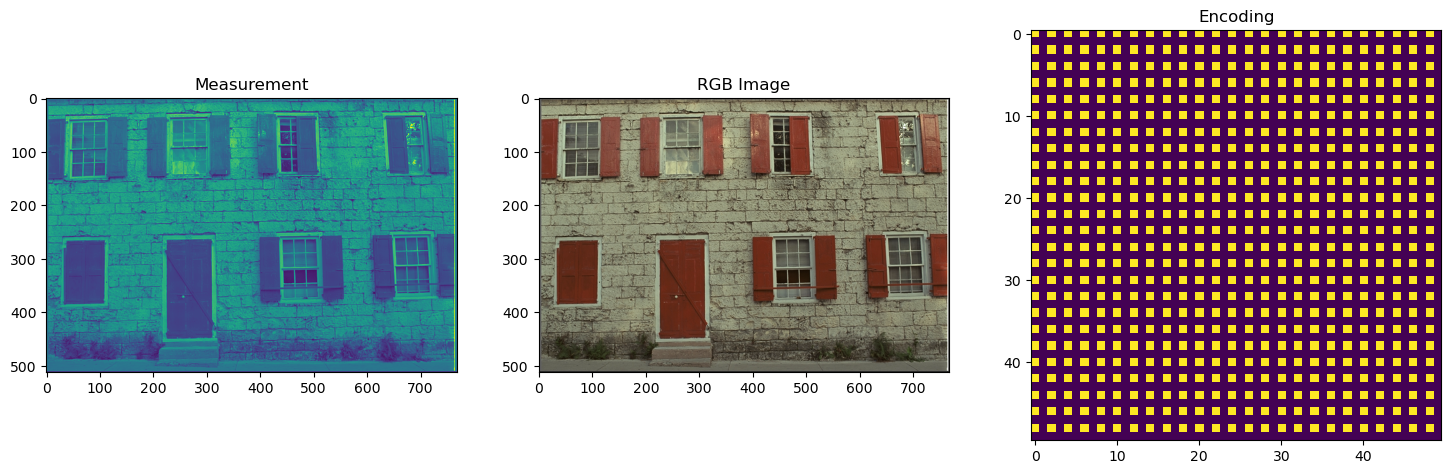

In [866]:
C = 3
B = np.zeros((2,2,C))
# Bayer Filter definition
B[0,0,0] = 1
B[1,1,2] = 1
B[0,1,1] = 1
B[1,0,1] = 1
#M, N= img.size
[M,N,L] = np.shape(img)
print(M,N)
T = np.zeros((M,N,C))
Y = np.zeros((M,N))
I = np.ones((M//2,N//2))
In= np.array(img)
#img.show()
for c in range(C):
    T[:,:,c] = np.kron(I,B[:,:,c])
    Y = Y + T[:,:,c]*In[:,:,c]
fig, axes = plt.subplots(1,3, figsize=(18,6))
axes[0].imshow(Y[:,:])
axes[0].set_title("Measurement")
axes[1].imshow(In/255, vmin=0, vmax=1)
axes[1].set_title("RGB Image")
axes[2].imshow(T[0:50,0:50,0], vmin=0, vmax=1)
axes[2].set_title("Encoding")

### Interpolación 2D o Demosaicking

El proceso recuperación empieza generando un tensor con las muestra y los valores no capturados
$\bar{\mathcal{I}}_c = \mathcal{T}_c \odot \mathbf{Y},$ luego para recuperar la imagen de color a partir del mosaico se realiza un filtrado por convolución entre el tensor de las muestras $\bar{\mathcal{I}}$ y el filtro $\mathcal{H}$ en cada canal 
$\hat{\mathcal{I}}_c = 0.25(\bar{\mathcal{I}}_c * \mathcal{H}_c),$ donde $*$ denota convolución, donde $\hat{\mathcal{I}}$ es la imagen RGB recuperada.

 
$\mathcal{H}_{0,2}=\begin{bmatrix}
1 & 2 & 1\\
2 & 4 & 2\\
1 & 2 & 1
\end{bmatrix},
$

$
\mathcal{H}_1=\begin{bmatrix}
0 & 1 & 0\\
1 & 4 & 1 \\
0 & 1 & 0
\end{bmatrix},
$

PSNR score:  26.007963441753695
SSIM score:  0.8165354909605279


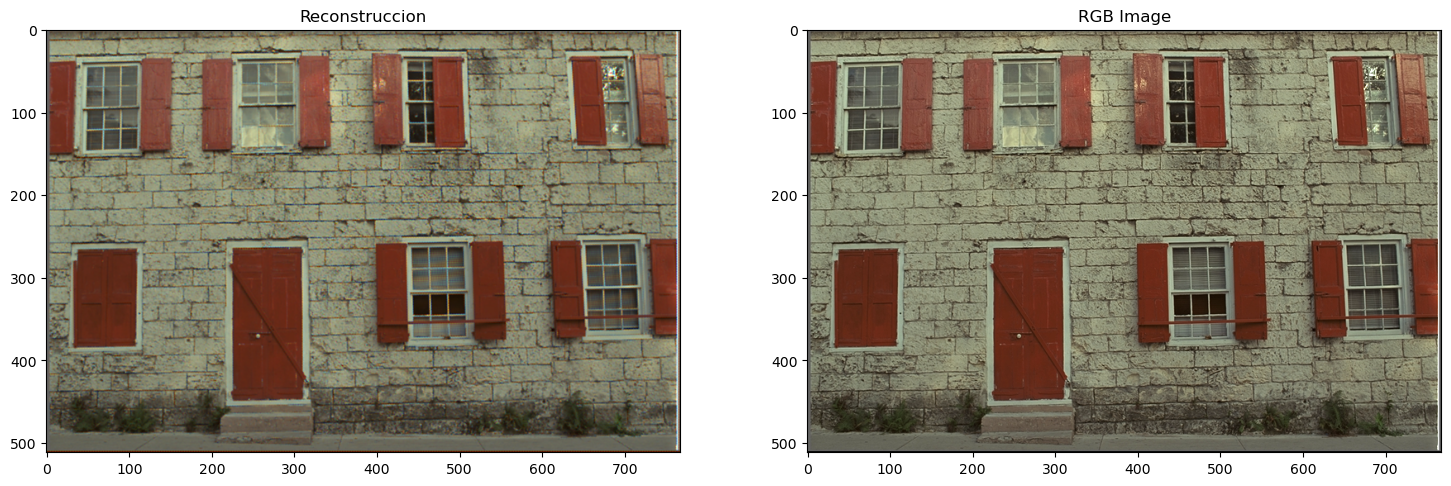

In [867]:
It = np.zeros((M,N,C),float)
Ir = np.zeros((M,N,C),float)

kernel = np.zeros((3, 3, 3))
kernel[:,:,0] = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]])
kernel[:,:,1] = np.array([[0, 1, 0], [1, 4, 1], [0, 1, 0]])
kernel[:,:,2] = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]])

'''Bilinear Demosaicking
'''

for c in range(C):
    It[:,:,c] = T[:,:,c]*Y
    Ir[:,:,c] = ndimage.correlate(It[:,:,c], kernel[:,:,c], mode='mirror')/4

#print(np.max(Ir),np.min(Ir))
Ir = np.uint8((Ir/np.max(Ir))*255)
fig, axes = plt.subplots(1,2, figsize=(18,6))
axes[0].imshow(Ir, vmin=0, vmax=1)
axes[0].set_title("Reconstruccion")
axes[1].imshow(In/255, vmin=0, vmax=1)
axes[1].set_title("RGB Image")
p = psnr(In,Ir)
s, diff = ssim(In,Ir,channel_axis=-1,full=True)
print("PSNR score: ",p)
print("SSIM score: ",s)